# TOPIC: Simple Logistic Regression.

### 1. Foundations & Model
- CoreBinary Target (y)
- Sigmoid / Logistic Function
- Weight/Coefficient
- Bias/Intercept
- Decision Boundary
### 2. Optimization & Loss Metrics
- Maximum Likelihood Estimation (MLE)
- Binary Cross-Entropy Loss (Log Loss)
### 3. Validation & Evaluation Techniques
- Validation Technique (Train-Test Split, K-Fold Cross Validation)
- Confusion Matrix & Metrics (Accuracy, Precision, Recall, F1-Score)
- ROC Curve & AUC Score
### 4. Overfitting Control & Tuning
- Underfitting/Overfitting
- L1 and L2 RegularizationRegularization Parameter (C)Threshold Tuning
### 5. Advanced Extensions.
- Multinomial / Softmax Regression
- Polynomial Logistic Regression

## A. Load and EDA Dataset. ##

In [1]:
import pandas as pd
social_media = pd.read_csv('Social_Network_Ads.csv')
social_media

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


In [3]:
print(f"Number of rows: {social_media.shape[0]}")
print(f"Number of columns: {social_media.shape[1]}")

Number of rows: 400
Number of columns: 5


In [4]:
social_media.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


In [5]:
social_media.describe()

,User ID,Age,EstimatedSalary,Purchased
count,4.000000e+02,400.000000,400.000000,400.000000
mean,1.569154e+07,37.655000,69742.500000,0.357500
std,7.165832e+04,10.482877,34096.960282,0.479864
min,1.556669e+07,18.000000,15000.000000,0.000000
25%,1.562676e+07,29.750000,43000.000000,0.000000
50%,1.569434e+07,37.000000,70000.000000,0.000000
75%,1.575036e+07,46.000000,88000.000000,1.000000
max,1.581524e+07,60.000000,150000.000000,1.000000


In [6]:
social_media.isnull().sum()

,0
User ID,0
Gender,0
Age,0
EstimatedSalary,0
Purchased,0


In [9]:
social_media.head(5)

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


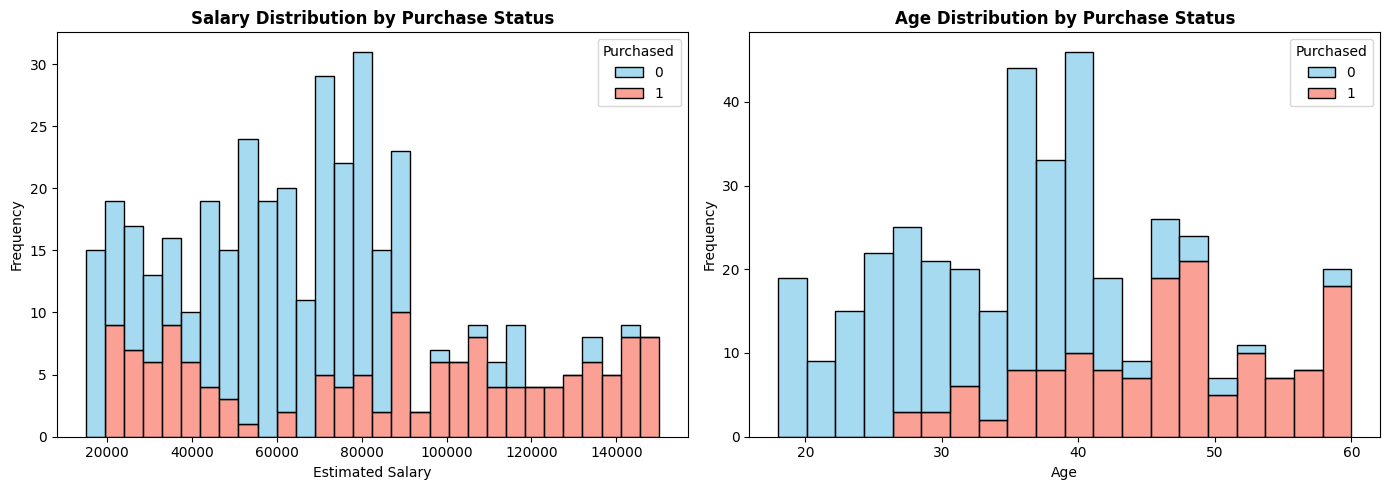

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
sns.histplot(data=social_media, x="EstimatedSalary", hue="Purchased",
             multiple="stack", palette=["skyblue", "salmon"], bins=30)
plt.title("Salary Distribution by Purchase Status", fontsize=12, fontweight="bold")
plt.xlabel("Estimated Salary", fontsize=10)
plt.ylabel("Frequency", fontsize=10)

plt.subplot(1, 2, 2)
sns.histplot(data=social_media, x="Age", hue="Purchased",
             multiple="stack", palette=["skyblue", "salmon"], bins=20)
plt.title("Age Distribution by Purchase Status", fontsize=12, fontweight="bold")
plt.xlabel("Age", fontsize=10)
plt.ylabel("Frequency", fontsize=10)
plt.tight_layout()
plt.show()

## B.Feature Engineering and & Train-Test Split. ##

In [16]:
from sklearn.model_selection import train_test_split
X = social_media[["Age"]]
y = social_media["Purchased"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Size of the training set: {X_train.shape[0]}")
print(f"Size of the testing set: {X_test.shape[0]}")

Size of the training set: 320
Size of the testing set: 80


## C. Train the Model. ##

In [17]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, y_train)

print(f"Hệ số góc (Coefficient / Weight): {model.coef_[0][0]:.4f}")
print(f"Trục tung (Intercept / Bias): {model.intercept_[0]:.4f}")

Hệ số góc (Coefficient / Weight): 0.1710
Trục tung (Intercept / Bias): -7.3238


## D. Evaluation the Model ##

In [18]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 91.25%

Confusion Matrix:
[[50  2]
 [ 5 23]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.96      0.93        52
           1       0.92      0.82      0.87        28

    accuracy                           0.91        80
   macro avg       0.91      0.89      0.90        80
weighted avg       0.91      0.91      0.91        80

